In [1]:
import numpy as np
import pandas as pd
import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500
import matplotlib.pyplot as plt

## Data

In [2]:
start_date = "2015-01-01"
end_date = "2023-12-31"
universe = qs.download(SP500, start_date, end_date)
factors = qs.download(
    ["SPY", "XLK"],
    start_date,
    end_date,
)
benchmark = qs.download("SPY", start_date, end_date)

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


In [3]:
vix = qs.download(["^VIX9D", "^VIX"], start_date, end_date)
vix = vix.close

In [4]:
returns_df = universe.returns
close_df = universe.close
volume_df = universe.volume
factor_returns = factors.returns
benchmark_returns = benchmark.returns

In [5]:
residuals_df, factor_params, factor_rsq = qs.residualize(returns_df, factor_returns)

## Baseline: Residual Mean Reversion

sharpe                              0.882145
ann_return                          0.212435
ann_vol                             0.255567
max_drawdown                         -0.4789
max_drawdown_duration                    217
max_drawdown_start       2015-05-11 00:00:00
max_drawdown_end         2016-03-18 00:00:00
avg_daily_turnover                  0.777049
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                        0.8374
information_ratio                   0.680211
dtype: object


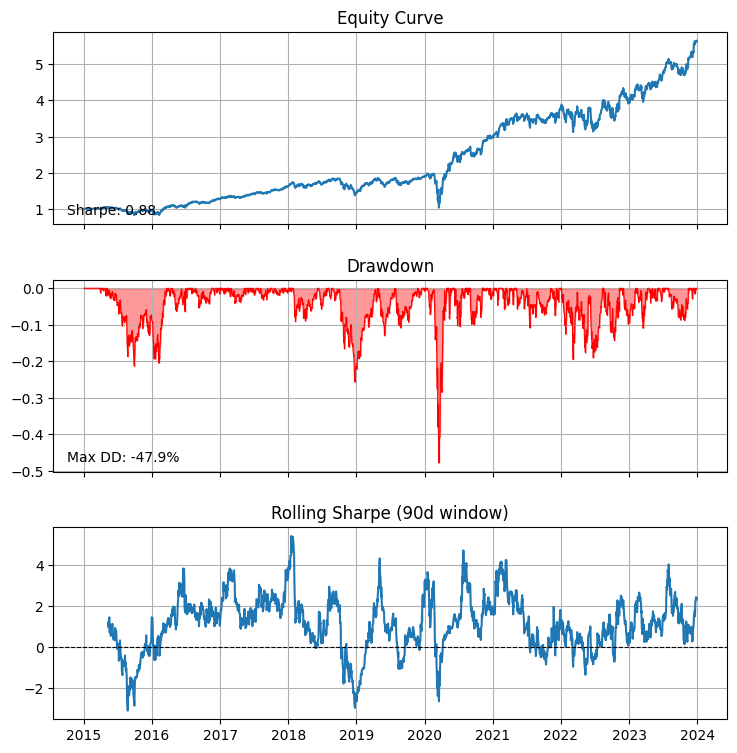

In [6]:
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# signal = qs.vix_contango_filter(signal, vix, 10)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

positions = qs.build_long_short_positions(signal, n_long=25, n_short=25)
port_ret = qs.run(positions, ret_filtered)

print(qs.metrics.summary(port_ret, positions, benchmark=benchmark_returns))
ax = qs.summary_plot(port_ret, figsize=(8, 8))

## Grid Search: Volume Filter

param_grid: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:23<00:00,  5.73it/s]


<Axes: title={'center': 'Volume Filter — Sharpe by (quantile, vol window)'}, xlabel='vol_wind', ylabel='qt'>

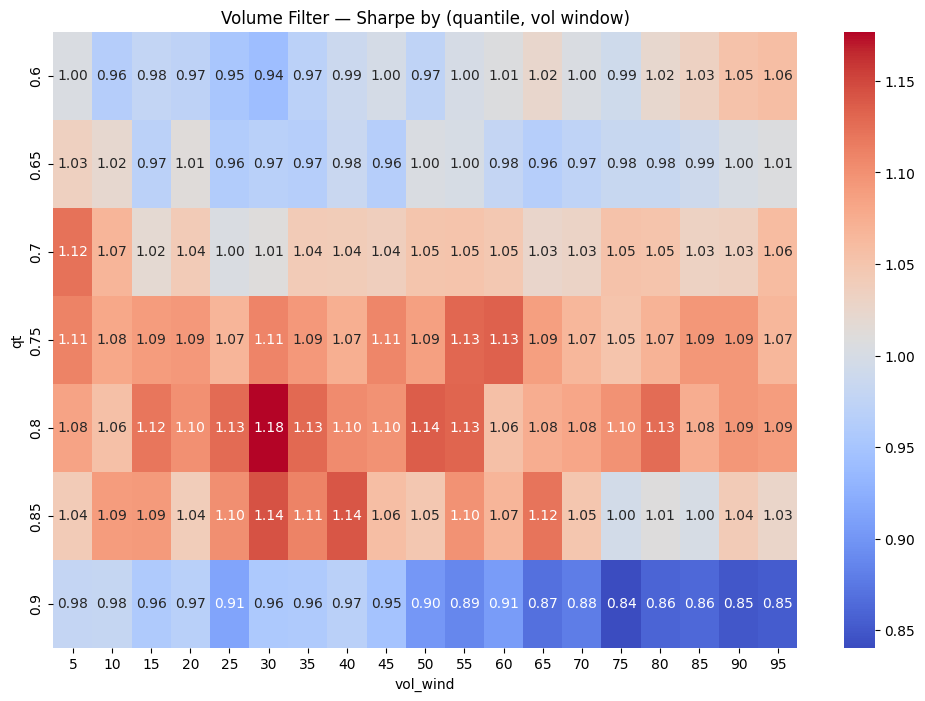

In [14]:
base_signal = -residuals_df.rolling(5).mean().shift(1)
base_signal = base_signal.sub(base_signal.mean(axis=1), axis=0)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
ret_filtered = returns_df.where(liq_mask)


def run_vol_filter(params):
    sig = qs.volume_zscore_filter(
        base_signal,
        volume_df,
        window=params["vol_wind"],
        min_zscore_quantile=params["qt"],
    )
    sig = sig.where(liq_mask)
    pos = qs.build_positions(sig, n_long=25, n_short=25)
    return qs.run(pos, ret_filtered)


results = qs.param_grid(
    {"vol_wind": list(range(5, 100, 5)), "qt": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]},
    run_vol_filter,
    metric_fn=qs.metrics.sharpe,
)

qs.param_heatmap(
    results,
    row_param="qt",
    col_param="vol_wind",
    metric="metric",
    title="Volume Filter — Sharpe by (quantile, vol window)",
    figsize=(12, 8),
)

## Grid Search: Signal Window & Strength Quantile

param_grid: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:04<00:00,  6.71it/s]


<Axes: title={'center': 'Signal Strength Filter — Sharpe by (quantile, window)'}, xlabel='wind', ylabel='qt'>

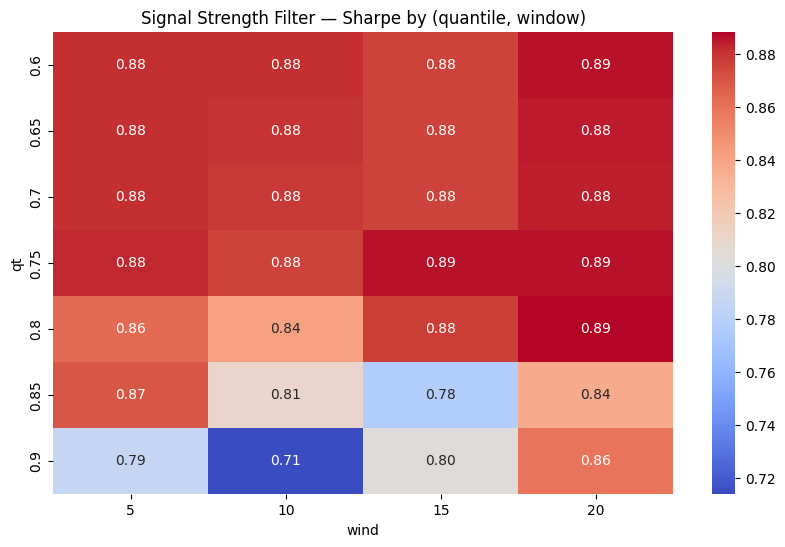

In [15]:
liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
ret_filtered = returns_df.where(liq_mask)


def run_signal_window(params):
    sig = -residuals_df.rolling(params["wind"]).mean().shift(1)
    sig = sig.sub(sig.mean(axis=1), axis=0)
    sig = sig.where(sig.abs().ge(sig.abs().quantile(params["qt"], axis=1), axis=0))
    sig = sig.where(liq_mask)
    pos = qs.build_positions(sig, n_long=25, n_short=25)
    return qs.run(pos, ret_filtered)


results = qs.param_grid(
    {"wind": [5, 10, 15, 20], "qt": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]},
    run_signal_window,
    metric_fn=qs.metrics.sharpe,
)

qs.param_heatmap(
    results,
    row_param="qt",
    col_param="wind",
    metric="metric",
    title="Signal Strength Filter — Sharpe by (quantile, window)",
)

## Grid Search: Residual Volatility Filter

param_grid: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:17<00:00,  7.44it/s]


<Axes: title={'center': 'Residual Vol Filter — Sharpe by (quantile, vol window)'}, xlabel='vol_wind', ylabel='qt'>

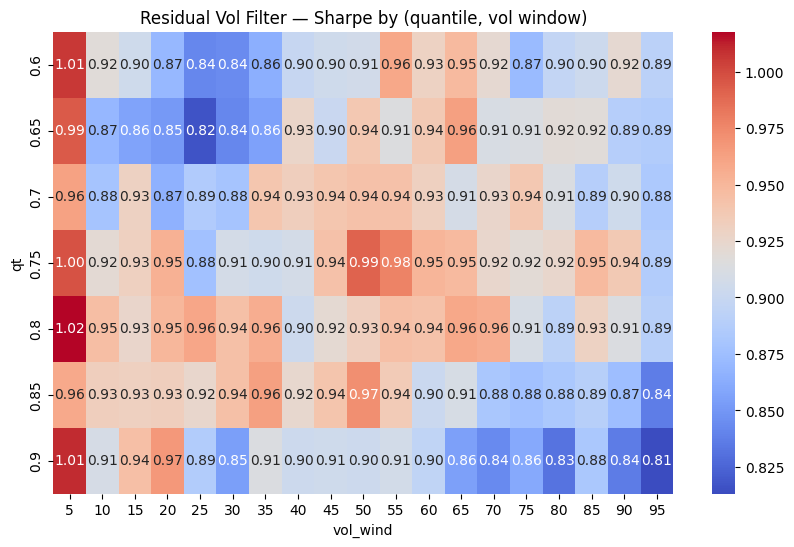

In [16]:
base_signal = -residuals_df.rolling(5).mean().shift(1)
base_signal = base_signal.sub(base_signal.mean(axis=1), axis=0)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
ret_filtered = returns_df.where(liq_mask)


def run_vol_filter_resid(params):
    realized_vol = residuals_df.rolling(params["vol_wind"]).std()
    sig = base_signal.where(realized_vol.lt(realized_vol.quantile(params["qt"], axis=1), axis=0))
    sig = sig.where(liq_mask)
    pos = qs.build_positions(sig, n_long=25, n_short=25)
    return qs.run(pos, ret_filtered)


results = qs.param_grid(
    {"vol_wind": list(range(5, 100, 5)), "qt": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]},
    run_vol_filter_resid,
    metric_fn=qs.metrics.sharpe,
)

qs.param_heatmap(
    results,
    row_param="qt",
    col_param="vol_wind",
    metric="metric",
    title="Residual Vol Filter — Sharpe by (quantile, vol window)",
)

## Best Combo: Volume + Residual Vol Filters

sharpe                              1.033589
ann_return                          0.195217
ann_vol                             0.190154
max_drawdown                        -0.35937
max_drawdown_duration                    440
max_drawdown_start       2022-03-31 00:00:00
max_drawdown_end         2023-12-29 00:00:00
avg_daily_turnover                  1.407339
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706394
benchmark_corr                      0.895191
information_ratio                   0.804771
dtype: object


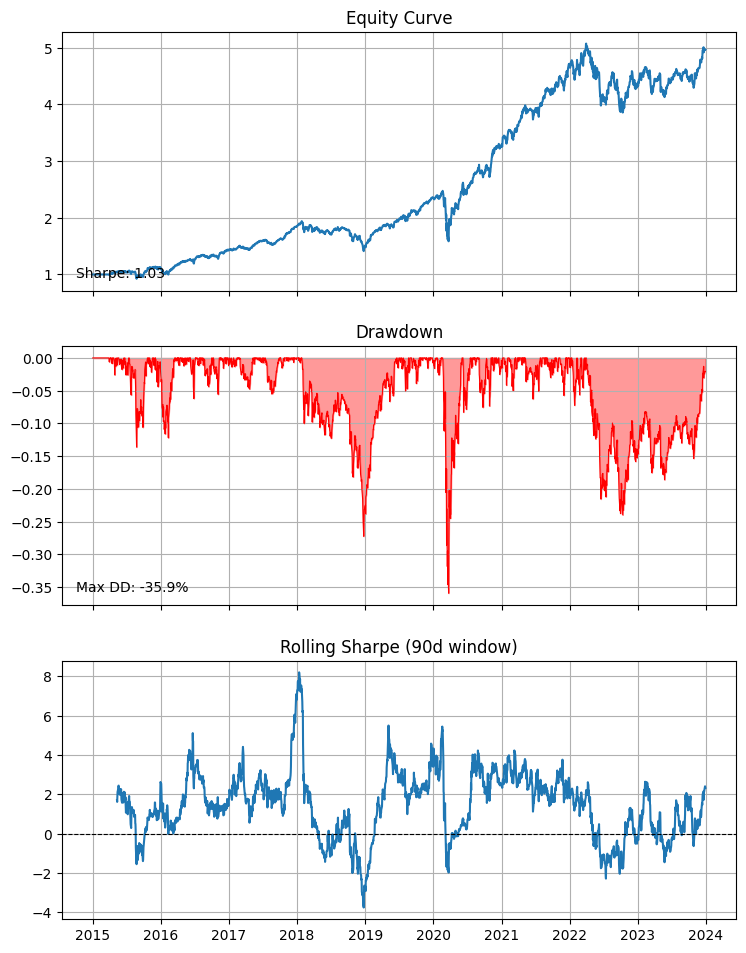

In [11]:
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

positions = qs.build_long_short_positions(signal, n_long=25, n_short=25)
port_ret = qs.run(positions, ret_filtered)

print(qs.metrics.summary(port_ret, positions, benchmark=benchmark_returns))
ax = qs.summary_plot(port_ret, figsize=(8, 10))

sharpe                              1.353841
ann_return                          0.193374
ann_vol                             0.137617
max_drawdown                       -0.187616
max_drawdown_duration                    197
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-11-30 00:00:00
avg_daily_turnover                  1.132958
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706394
benchmark_corr                      0.656993
information_ratio                   0.425017
dtype: object


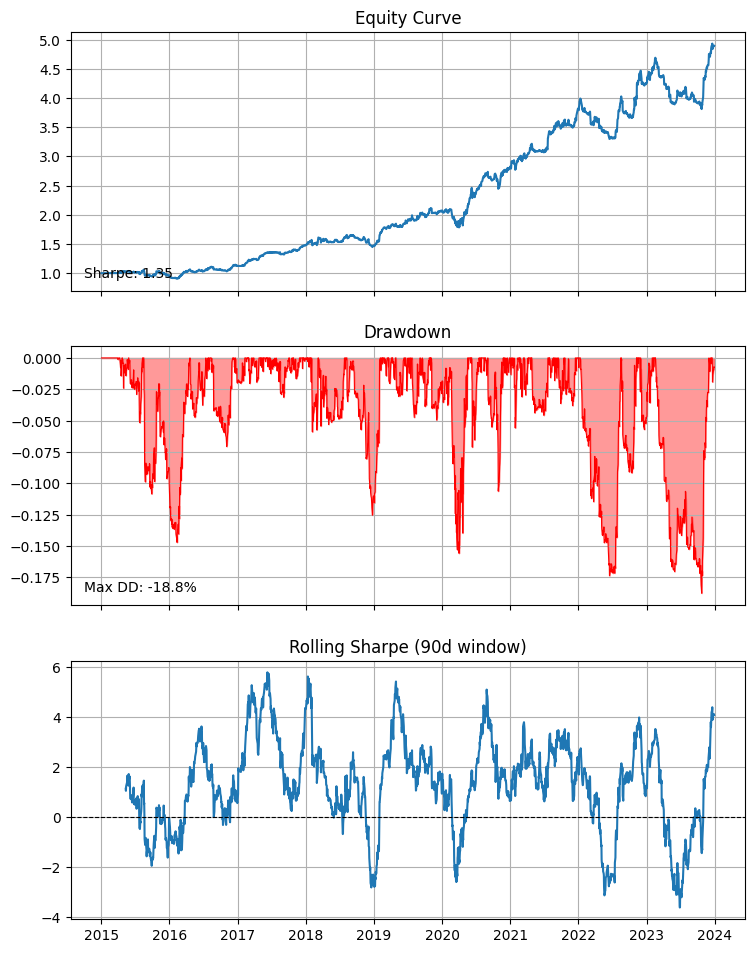

In [6]:
# -------------------------------------------------------------------
# residual mean reversion base signal
# -------------------------------------------------------------------
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# -------------------------------------------------------------------
# conditioning filters
# -------------------------------------------------------------------
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)

med_mom = residuals_df.rolling(60).mean()
signal = signal.where(med_mom.abs().lt(med_mom.quantile(0.7, axis=1), axis=0))

# -------------------------------------------------------------------
# liquidity universe
# -------------------------------------------------------------------

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

# -------------------------------------------------------------------
# portfolio construction
# -------------------------------------------------------------------

positions = qs.build_long_short_positions(signal, n_long=25, n_short=25)

# -------------------------------------------------------------------
# raw strategy returns
# -------------------------------------------------------------------

raw_port_ret = qs.run(positions, ret_filtered)

# -------------------------------------------------------------------
# equity curve regime filter
# if strategy equity < 100d MA:
# reduce exposure
# -------------------------------------------------------------------

equity_curve = (1 + raw_port_ret).cumprod()
equity_ma = equity_curve.rolling(20).mean()

# 50% exposure below MA
exposure_scale = pd.Series(np.where(equity_curve > equity_ma, 1.0, 0.25), index=equity_curve.index)

# for full shutdown instead:
# exposure_scale = np.where(equity_curve > equity_ma, 1.0, 0.0)

scaled_positions = positions.mul(exposure_scale.shift(1), axis=0)

# -------------------------------------------------------------------
# final returns
# -------------------------------------------------------------------
port_ret = qs.run(scaled_positions, ret_filtered)

# -------------------------------------------------------------------
# diagnostics
# -------------------------------------------------------------------

print(qs.metrics.summary(port_ret, scaled_positions, benchmark=benchmark_returns))

ax = qs.summary_plot(port_ret, figsize=(8, 10))

In [7]:
sector_map = qs.get_sector_map(SP500)

residual_mean_reversion:   0%|                                                                                                                     | 0/13 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


residual_mean_reversion: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 18.51it/s, stage=metrics]


sharpe                              1.353483
ann_return                          0.193313
ann_vol                             0.137615
max_drawdown                       -0.187616
max_drawdown_duration                    197
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-11-30 00:00:00
avg_daily_turnover                  1.132921
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.656989
information_ratio                   0.424637


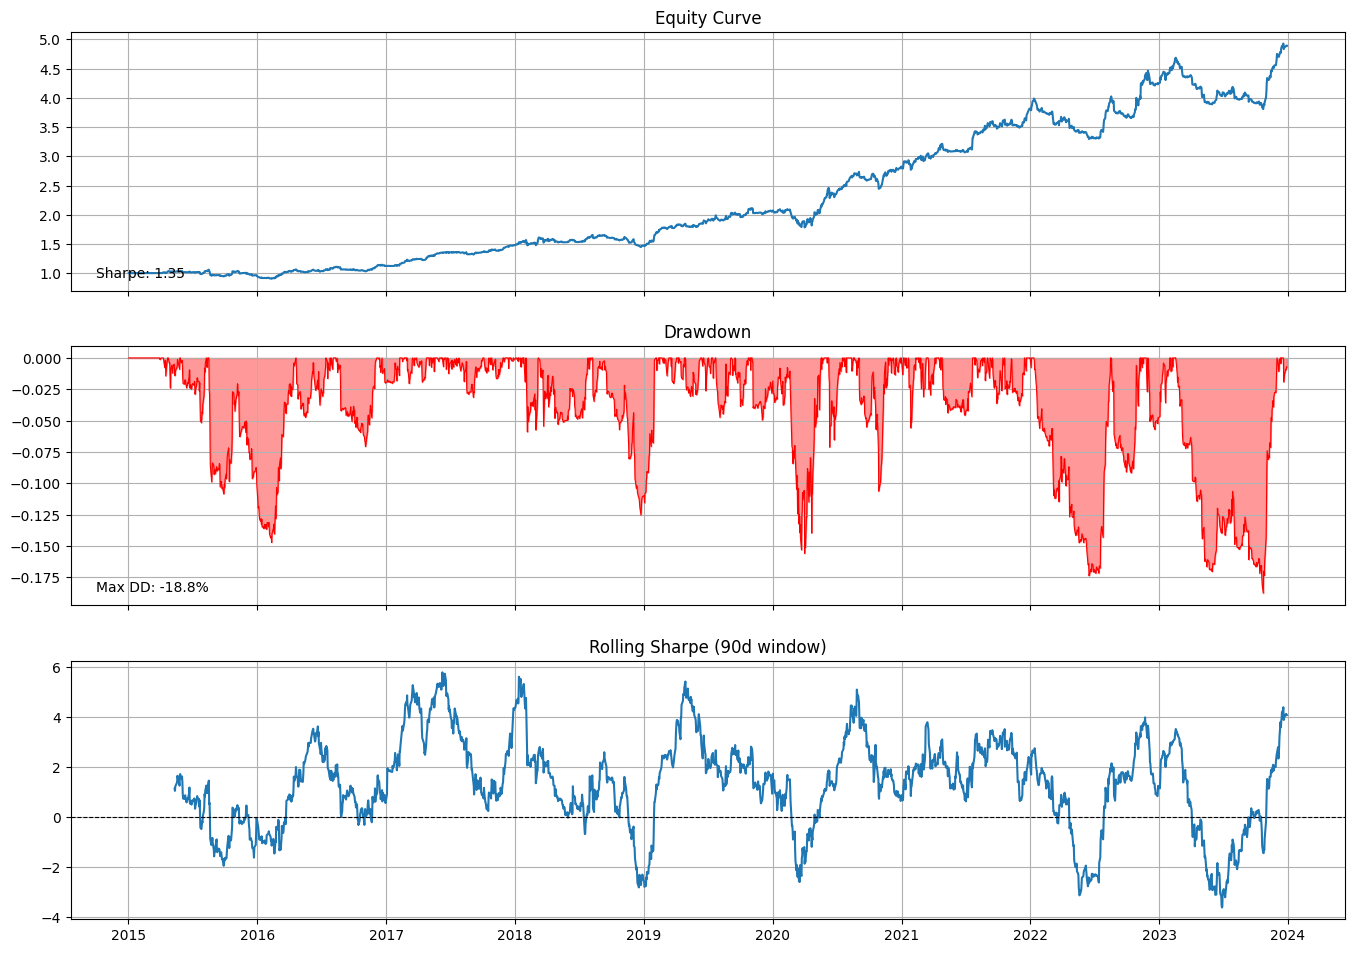

Study(name='residual_mean_reversion', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=False, ran=True)

In [9]:
"""
Residual Mean Reversion — rewritten using the Study pipeline.

Original: manual steps using raw qstudy functions.
This version: same strategy expressed as a Study pipeline.

The equity-curve regime filter (scale to 0.25x when below 20-day MA)
is the one step that requires a custom function since it's not a
built-in filter. Everything else maps directly to pipeline methods.
"""

# ---------------------------------------------------------------------------
# Custom signal mutation
# ---------------------------------------------------------------------------
# The original code demeaned the signal after computing it:
#   signal = signal.sub(signal.mean(axis=1), axis=0)
# This is a signal mutation (not a filter), so we pass it as add_filter.
# We return the same shape — no cells are zeroed, just re-centered.

def mr_signal(**cache):
    return -cache["residual_returns"].rolling(5).mean().shift(1)

def demean_signal(signal, **cache):
    """Cross-sectionally demean the signal each day."""
    return signal.sub(signal.mean(axis=1), axis=0)

# ---------------------------------------------------------------------------
# Custom position scaler: equity-curve regime filter
# ---------------------------------------------------------------------------
# Scale positions to 0.25x when the cumulative equity curve is below its
# 20-day moving average, full exposure (1.0x) when above.

def equity_curve_regime_scale(positions, **cache):
    returns = cache["returns"]
    mask = cache.get("_tradeable_mask")
    if mask is None:
        mask = cache.get("_liquidity_mask")
    if mask is not None:
        returns = returns.where(mask)
    raw_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_ret).cumprod()
    equity_ma = equity.rolling(20).mean()
    scale = pd.Series(np.where(equity > equity_ma, 1.0, 0.25), index=equity.index)
    return positions.mul(scale.shift(1), axis=0)


# ---------------------------------------------------------------------------
# Pipeline
# ---------------------------------------------------------------------------

study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="residual_mean_reversion",
    )
    .residualize_returns()  # produces residual_returns in cache
    .base_signal(mr_signal)  # signal = -residuals.rolling(5).mean().shift(1)
    .transform_signal(demean_signal)  # signal = signal.sub(signal.mean(axis=1), axis=0)
    .add_vol_filter(vol_window=5, quantile=0.6)
    .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
    .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
    .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
    .build_long_short(n_long=25, n_short=25)  # qs.build_long_short_positions(signal, 25, 25)
    .rebalance(every=1)
    .scale_risk(equity_curve_regime_scale)  # 0.25x exposure when below 20-day equity MA
    .run()
)

study.report()

sharpe                              1.359147
ann_return                          0.194209
ann_vol                             0.137592
max_drawdown                       -0.187615
max_drawdown_duration                    197
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-11-30 00:00:00
avg_daily_turnover                  1.133523
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.656683
information_ratio                   0.429912
dtype: object


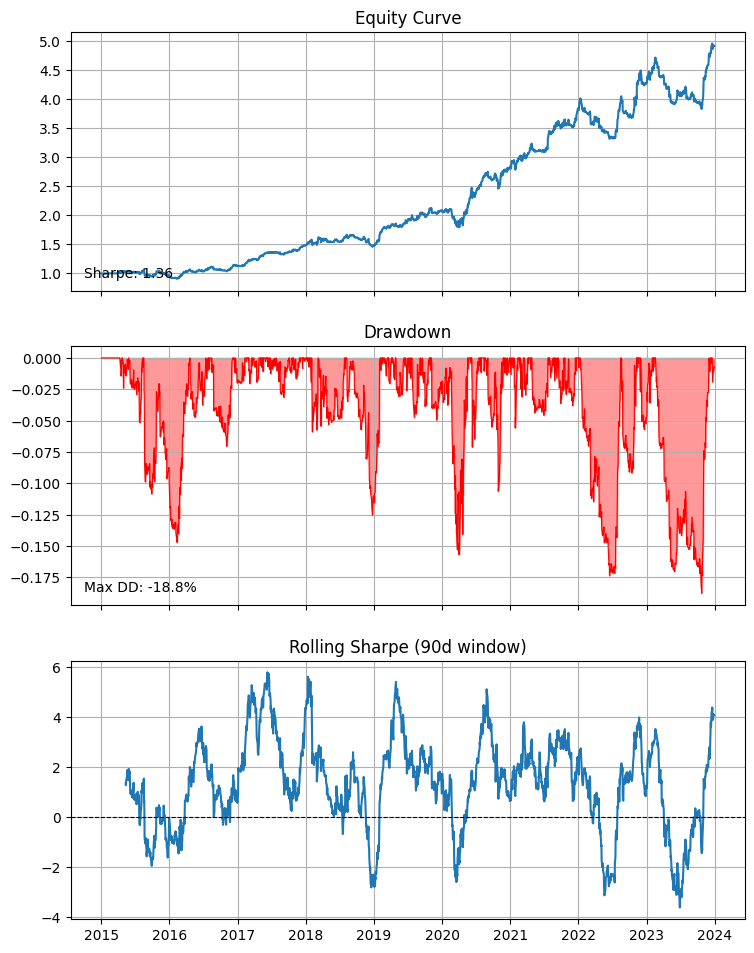

In [21]:
# -------------------------------------------------------------------
# residual mean reversion base signal
# -------------------------------------------------------------------

signal = -residuals_df.rolling(60).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# -------------------------------------------------------------------
# conditioning filters
# -------------------------------------------------------------------
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)
med_mom = residuals_df.rolling(60).mean()
signal = signal.where(med_mom.abs().lt(med_mom.quantile(0.7, axis=1), axis=0))

# -------------------------------------------------------------------
# liquidity universe
# -------------------------------------------------------------------

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

# -------------------------------------------------------------------
# portfolio construction
# -------------------------------------------------------------------
positions = qs.build_long_short_positions(signal, n_long=25, n_short=25)

# -------------------------------------------------------------------
# raw strategy returns
# -------------------------------------------------------------------
raw_port_ret = qs.run(positions, ret_filtered)

# -------------------------------------------------------------------
# equity curve regime filter
# -------------------------------------------------------------------
equity_curve = (1 + raw_port_ret).cumprod()
equity_ma = equity_curve.rolling(20).mean()
exposure_scale = pd.Series(np.where(equity_curve > equity_ma, 1.0, 0.25), index=equity_curve.index)
scaled_positions = positions.mul(exposure_scale.shift(1), axis=0)

# -------------------------------------------------------------------
# final returns
# -------------------------------------------------------------------
port_ret = qs.run(scaled_positions, ret_filtered)

# -------------------------------------------------------------------
# diagnostics
# -------------------------------------------------------------------

print(qs.metrics.summary(port_ret, scaled_positions, benchmark=benchmark_returns))

ax = qs.summary_plot(port_ret, figsize=(8, 10))

## proportional weighting

sharpe                              1.092315
ann_return                           0.11575
ann_vol                             0.105359
max_drawdown                       -0.161166
max_drawdown_duration                    310
max_drawdown_start       2017-02-02 00:00:00
max_drawdown_end         2018-04-26 00:00:00
avg_daily_turnover                  0.169754
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.072323
information_ratio                  -0.062727
dtype: object


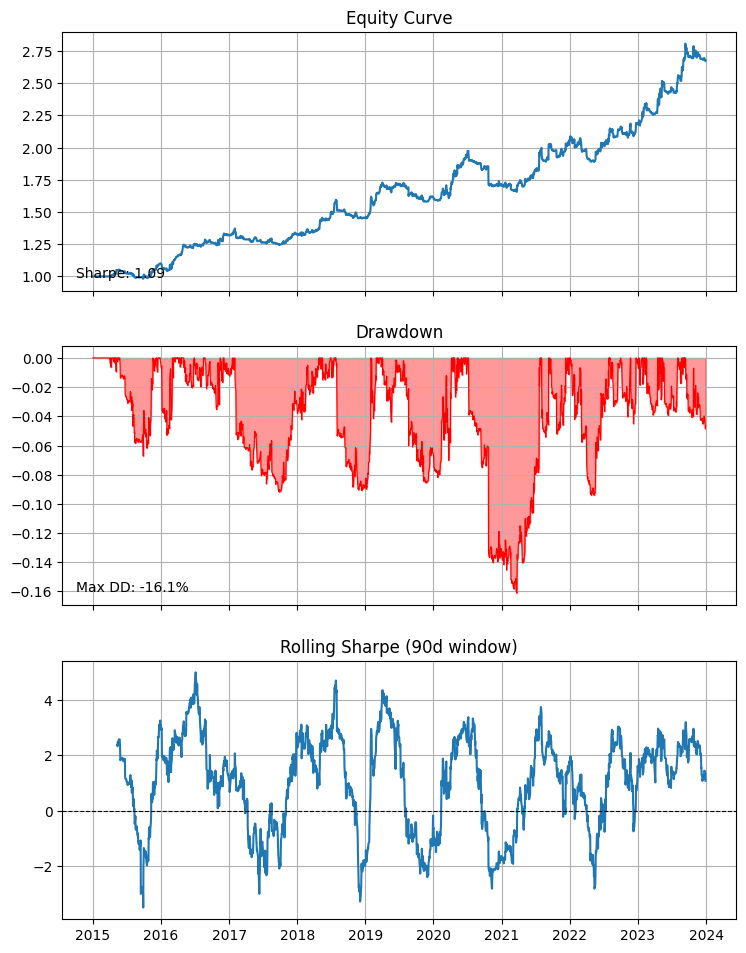

In [6]:
# -------------------------------------------------------------------
# residual mean reversion base signal
# -------------------------------------------------------------------
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# -------------------------------------------------------------------
# conditioning filters
# -------------------------------------------------------------------
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)
med_mom = residuals_df.rolling(60).mean()
signal = signal.where(med_mom.abs().lt(med_mom.quantile(0.7, axis=1), axis=0))

# -------------------------------------------------------------------
# liquidity universe
# -------------------------------------------------------------------

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

# -------------------------------------------------------------------
# proportional-weight portfolio construction
# instead of hard top/bottom buckets
# -------------------------------------------------------------------
signal_z = signal.sub(signal.mean(axis=1), axis=0)
signal_std = signal.std(axis=1)
signal_z = signal_z.div(signal_std, axis=0)
# optional clipping to avoid concentration
signal_z = signal_z.clip(-3, 3)
positions = signal_z.div(signal_z.abs().sum(axis=1), axis=0)

# -------------------------------------------------------------------
# raw strategy returns
# -------------------------------------------------------------------
raw_port_ret = qs.run(positions, ret_filtered)

# -------------------------------------------------------------------
# equity curve regime filter
# -------------------------------------------------------------------
equity_curve = (1 + raw_port_ret).cumprod()
equity_ma = equity_curve.rolling(20).mean()
exposure_scale = pd.Series(np.where(equity_curve > equity_ma, 1.0, 0.25), index=equity_curve.index)
scaled_positions = positions.mul(exposure_scale.shift(1), axis=0)

# -------------------------------------------------------------------
# final returns
# -------------------------------------------------------------------
port_ret = qs.run(scaled_positions, ret_filtered)

# -------------------------------------------------------------------
# diagnostics
# -------------------------------------------------------------------
print(qs.metrics.summary(port_ret, scaled_positions, benchmark=benchmark_returns))
ax = qs.summary_plot(port_ret, figsize=(8, 10))

residual_mean_reversion:   0%|                                                                                                                     | 0/13 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


residual_mean_reversion: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 18.73it/s, stage=metrics]


sharpe                              0.111754
ann_return                         -0.075099
ann_vol                             0.518005
max_drawdown                       -0.918604
max_drawdown_duration                   1364
max_drawdown_start       2018-07-31 00:00:00
max_drawdown_end         2023-12-29 00:00:00
avg_daily_turnover                  3.877772
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.193868
information_ratio                  -0.135873


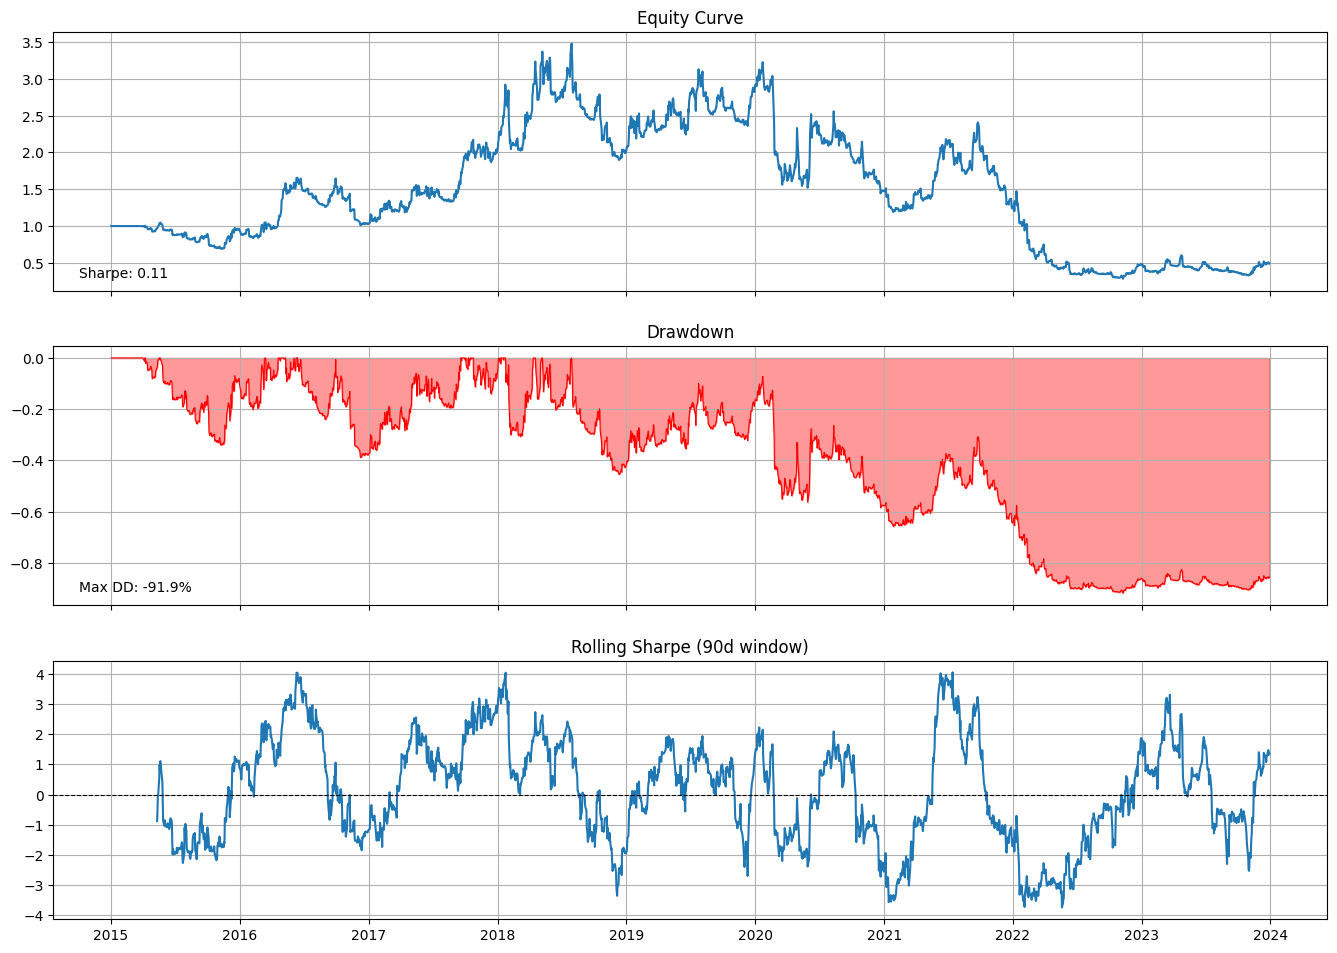

Study(name='residual_mean_reversion', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=False, ran=True)

In [8]:
def demean_signal(signal, **cache):
    """Cross-sectionally demean the signal each day."""
    return signal.sub(signal.mean(axis=1), axis=0)

def equity_curve_regime_scale(positions, **cache):
    returns = cache["returns"]
    mask = cache.get("_tradeable_mask")
    
    if mask is None:
        mask = cache.get("_liquidity_mask")
    if mask is not None:
        returns = returns.where(mask)
        
    raw_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_ret).cumprod()
    equity_ma = equity.rolling(20).mean()
    scale = pd.Series(np.where(equity > equity_ma, 1.0, 0.25), index=equity.index)
    return positions.mul(scale.shift(1), axis=0)

def proportional_positions(signal, **cache):
    signal_z = signal.sub(signal.mean(axis=1), axis=0)
    signal_z = signal_z.div(signal_z.std(axis=1), axis=0)
    signal_z = signal_z.clip(-3, 3)
    signal_z = signal_z.sub(signal_z.mean(axis=1), axis=0)  # re-demean after clip
    positions = signal_z.div(signal_z.abs().sum(axis=1), axis=0)
    last = signal.dropna(how='all').iloc[-1].dropna()

    return positions

def mr_signal(**cache):
    return -cache["residual_returns"].rolling(5).mean().shift(1)
    
study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="residual_mean_reversion",
    )
    .residualize_returns()  # produces residual_returns in cache
    .base_signal(mr_signal)  # signal = -residuals.rolling(5).mean().shift(1)
    .transform_signal(demean_signal)  # signal = signal.sub(signal.mean(axis=1), axis=0)
    .add_vol_filter(vol_window=5, quantile=0.6)
    .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
    .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
    .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
    .build_positions(proportional_positions)
    .rebalance(every=1)
    .scale_risk(equity_curve_regime_scale)  # 0.25x exposure when below 20-day equity MA
    .run()
)

study.report()

## Correlation

/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_44589/1086847746.py:52: DeprecationWarning: add_liquidity_filter() is deprecated. Use .add_tradeable_constraint(qs.liquidity(top_n, window)) instead.
  Study(
/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_44589/1086847746.py:66: DeprecationWarning: scale_returns() is deprecated. Use .scale_risk(fn) instead.
  .scale_returns(equity_curve_regime_scale)
/var/folders/8_/wzdkmfn13sd6lvk4c6xz3cph0000gp/T/ipykernel_44589/1086847746.py:67: DeprecationWarning: scale_returns() is deprecated. Use .scale_risk(fn) instead.
  .scale_returns(corr_regime_scale)
residual_mr_5d_corr_filter:   0%|                                                                                                                  | 0/13 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


residual_mr_5d_corr_filter: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:42<00:00,  3.24s/it, stage=metrics]


sharpe                              1.212155
ann_return                          0.152818
ann_vol                             0.123655
max_drawdown                        -0.15268
max_drawdown_duration                    196
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-11-29 00:00:00
avg_daily_turnover                  0.951281
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706394
benchmark_corr                      0.554157
information_ratio                   0.144956


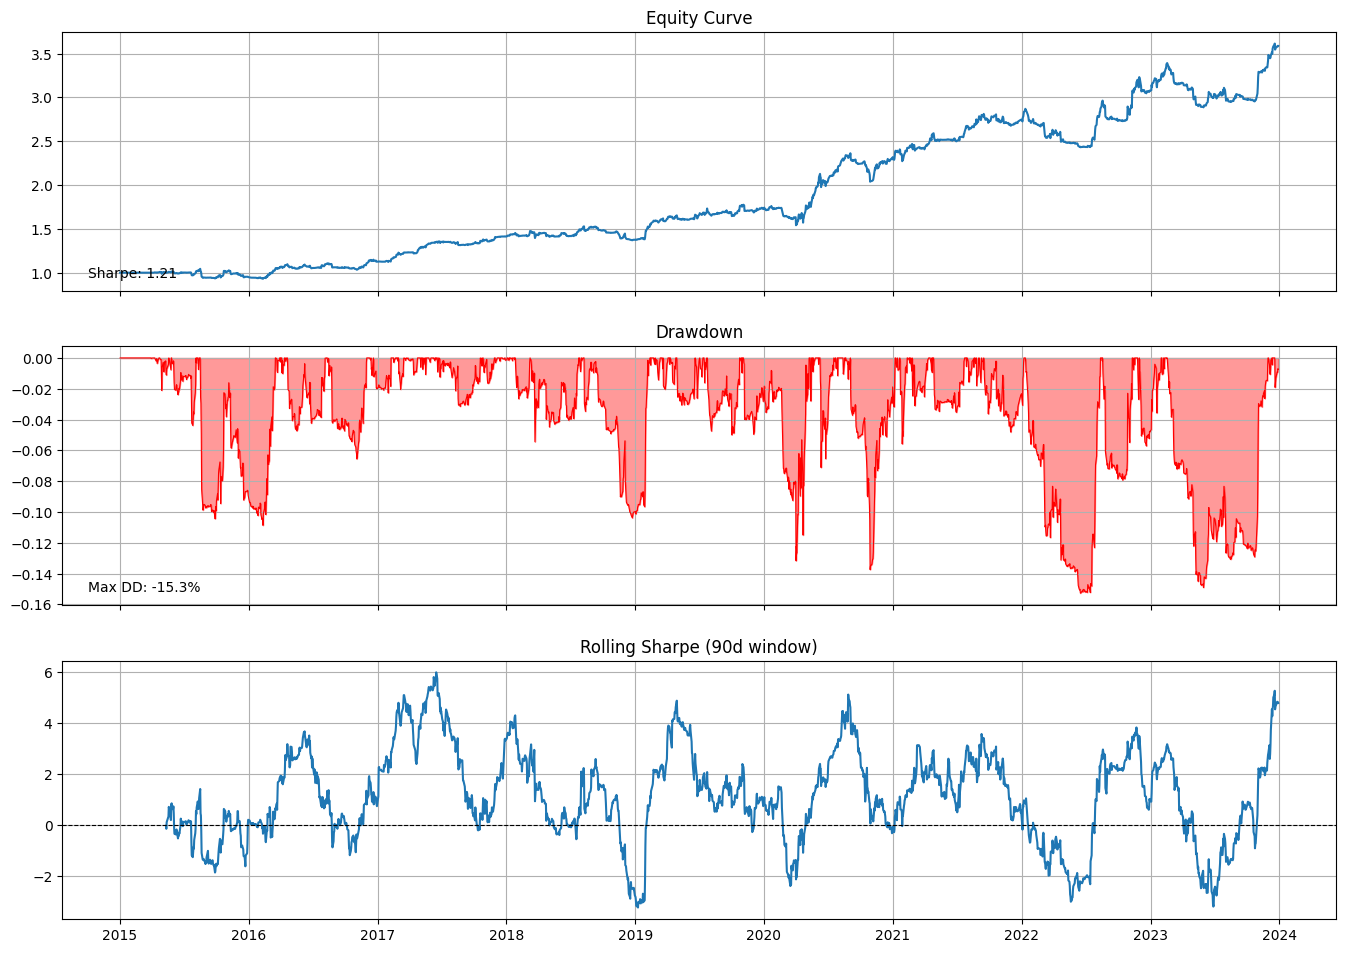

Study(name='residual_mr_5d_corr_filter', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=False, ran=True)

In [12]:
"""
Residual Mean Reversion (5-day) with Correlation Regime Filter — Study pipeline version.

Strategy:
- Signal: negative 5-day rolling mean of residual returns
- Filters: vol, volume z-score, momentum context, liquidity
- Scalers: equity-curve regime (0.25x below 20-day MA) * cross-sectional correlation regime
           (0.25x when avg correlation is above its 80th percentile rolling threshold)
"""
def mr_signal(**cache):
    return -cache["residual_returns"].rolling(5).mean().shift(1)

def demean_signal(signal, **cache):
    """Cross-sectionally demean the signal each day."""
    return signal.sub(signal.mean(axis=1), axis=0)


def equity_curve_regime_scale(positions, **cache):
    """Scale down to 25% exposure when equity curve is below its 20-day MA."""
    returns = cache["returns"]
    liq_mask = cache.get("_liquidity_mask")
    if liq_mask is not None:
        returns = returns.where(liq_mask)
    raw_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_ret).cumprod()
    equity_ma = equity.rolling(20).mean()
    scale = pd.Series(
        np.where(equity > equity_ma, 1.0, 0.25),
        index=equity.index,
    )
    return positions.mul(scale.shift(1), axis=0)


def corr_regime_scale(positions, **cache):
    """Scale down to 25% exposure when avg cross-sectional correlation exceeds its 80th pctile.

    Mean reversion tends to fail when correlations spike — stocks move together rather than
    reverting to idiosyncratic levels.
    """
    returns = cache["returns"]
    corr_window = 20
    avg_corr = returns.rolling(corr_window).corr().groupby(level=0).mean().mean(axis=1)
    corr_thresh = avg_corr.rolling(60).quantile(0.8)
    scale = pd.Series(
        np.where(avg_corr < corr_thresh, 1.0, 0.25),
        index=avg_corr.index,
    )
    return positions.mul(scale.shift(1), axis=0)


study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="residual_mr_5d_corr_filter",
    )
    .residualize_returns()
    .base_signal(mr_signal)
    .add_filter(demean_signal)
    .add_vol_filter(vol_window=5, quantile=0.6)
    .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
    .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
    .add_liquidity_filter(top_n=250)
    .build_long_short(n_long=25, n_short=25)
    .scale_returns(equity_curve_regime_scale)
    .scale_returns(corr_regime_scale)
    .run()
)

study.report()

sharpe                              1.147383
ann_return                          0.126047
ann_vol                             0.108618
max_drawdown                       -0.161358
max_drawdown_duration                    217
max_drawdown_start       2023-02-21 00:00:00
max_drawdown_end         2023-12-29 00:00:00
avg_daily_turnover                  0.772564
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                       0.46137
information_ratio                  -0.019518
dtype: object


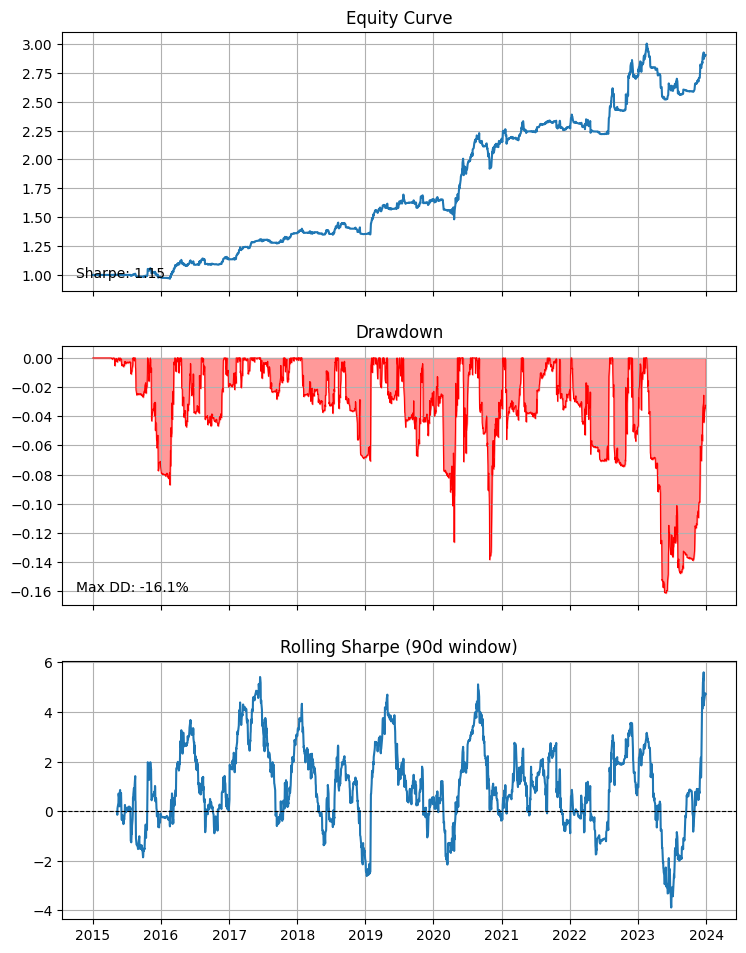

In [24]:
# -------------------------------------------------------------------
# residual mean reversion base signal
# -------------------------------------------------------------------
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

# -------------------------------------------------------------------
# conditioning filters
# -------------------------------------------------------------------
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)
med_mom = residuals_df.rolling(60).mean()
signal = signal.where(med_mom.abs().lt(med_mom.quantile(0.7, axis=1), axis=0))

# -------------------------------------------------------------------
# liquidity universe
# -------------------------------------------------------------------
liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)

signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

# -------------------------------------------------------------------
# portfolio construction
# -------------------------------------------------------------------
positions = qs.build_long_short_positions(signal, n_long=25, n_short=25)

# -------------------------------------------------------------------
# raw strategy returns
# -------------------------------------------------------------------
raw_port_ret = qs.run(positions, ret_filtered)

# -------------------------------------------------------------------
# equity curve regime filter
# -------------------------------------------------------------------
equity_curve = (1 + raw_port_ret).cumprod()
equity_ma = equity_curve.rolling(20).mean()
equity_scale = pd.Series(np.where(equity_curve > equity_ma, 1.0, 0.25), index=equity_curve.index)

# -------------------------------------------------------------------
# cross-sectional correlation filter
# MR tends to fail when correlations spike
# -------------------------------------------------------------------
corr_window = 20
avg_corr = returns_df.rolling(corr_window).corr().groupby(level=0).mean().mean(axis=1)
corr_thresh = avg_corr.rolling(60).quantile(0.8)
corr_scale = pd.Series(np.where(avg_corr < corr_thresh, 1.0, 0.25), index=avg_corr.index)

# -------------------------------------------------------------------
# market breadth filter
# MR tends to struggle when too few stocks are in healthy trends
# -------------------------------------------------------------------
ma_200 = close_df.rolling(200).mean()
above_200 = close_df > ma_200
pct_above_200dma = above_200.mean(axis=1)
breadth_thresh = pct_above_200dma.rolling(60).quantile(0.3)

breadth_scale = pd.Series(
    np.where(pct_above_200dma > breadth_thresh, 1.0, 0.25), index=pct_above_200dma.index
)

# -------------------------------------------------------------------
# combine regime filters
# -------------------------------------------------------------------
total_scale = equity_scale * corr_scale * breadth_scale
scaled_positions = positions.mul(total_scale.shift(1), axis=0)

# -------------------------------------------------------------------
# final returns
# -------------------------------------------------------------------
port_ret = qs.run(scaled_positions, ret_filtered)

# -------------------------------------------------------------------
# diagnostics
# -------------------------------------------------------------------
print(qs.metrics.summary(port_ret, scaled_positions, benchmark=benchmark_returns))

ax = qs.summary_plot(port_ret, figsize=(8, 10))